<a href="https://colab.research.google.com/github/lejhindary/MedStar-G5/blob/main/MedStarG5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import learning_curve

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_folder = "/content/drive/MyDrive/Group 5: Dereck Kaale/MIMIC-IV-ExtCardiacDiseases/Dataset"
os.listdir(data_folder)
mimic_folder = "/content/drive/MyDrive/Group 5: Dereck Kaale/mimiciv/3.1/"
os.listdir(mimic_folder)

Mounted at /content/drive


['CHANGELOG.txt', 'LICENSE.txt', 'SHA256SUMS.txt', 'index.html', 'hosp', 'icu']

In [ ]:
import os

# This is the path to the 'Group 5: Dereck Kaale' folder in your Drive
parent_data_path = "/content/drive/MyDrive/Group 5: Dereck Kaale/"

print(f"Checking contents of: {parent_data_path}")

if os.path.exists(parent_data_path):
    print("\nContents found:")
    for item in os.listdir(parent_data_path):
        print(f"- {item}")
    print("\nLook for a folder similar to 'MIMIC-IV-ExtCardiacDiseases' in the list above.")
    print("Once you find the correct folder name (e.g., 'MIMIC-IV-ExtCardiacDiseases_Corrected'),")
    print("you should update the `data_folder` variable in cell `z6JBTLhEwYxb` to reflect that exact path.")
    print("For example: `data_folder = \"/content/drive/MyDrive/Group 5: Dereck Kaale/MIMIC-IV-ExtCardiacDiseases_Corrected/Dataset\"`")
else:
    print(f"\nError: The directory '{parent_data_path}' does not exist. Please ensure your Google Drive is mounted correctly and this path is valid.")
    print("You might need to re-run `drive.mount('/content/drive')` or check the path to 'Group 5: Dereck Kaale'.")

Checking contents of: /content/drive/MyDrive/Group 5: Dereck Kaale/

Contents found:
- Summer 26 Intern Proposal- Dereck Kaale.pptx
- Group 5 Team.gslides
- AI Colab Internship Summer  2026  - Group 5.pptx
- 1. Project charter Grp 5 Summer 2026.pdf
- Draft timeline.pdf
- MIMIC-IV-ExtCardiacDiseases
- Literature review.gsheet
- Summer 2026 AICL Internship Syllabus.docx
- mimiciv
- Meeting summaries.gslides
- MedStarG5.ipynb
- Literature.gdoc

Look for a folder similar to 'MIMIC-IV-ExtCardiacDiseases' in the list above.
Once you find the correct folder name (e.g., 'MIMIC-IV-ExtCardiacDiseases_Corrected'),
you should update the `data_folder` variable in cell `z6JBTLhEwYxb` to reflect that exact path.
For example: `data_folder = "/content/drive/MyDrive/Group 5: Dereck Kaale/MIMIC-IV-ExtCardiacDiseases_Corrected/Dataset"`


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
heart_diagnoses = pd.read_csv(data_folder+"/heart_labevents_examination_group.csv")
true_heart_diagnoses = pd.read_csv(data_folder+"/heart_diagnoses_all_true.csv")

In [ ]:
true_heart_diagnoses[(true_heart_diagnoses['icd_code']=="I359") | (true_heart_diagnoses['icd_code']=="I350")].value_counts()

#I359 = nonrheumatic aortic valve disorder unspecified
#I350 nonrheumatic aortic valve stenosis
#I348 other nonrheumatic mitral valve disorder

,,,,,count
subject_id,hadm_id,seq_num,icd_code,long_title,
19965144,28838567,4,I359,"Nonrheumatic aortic valve disorder, unspecified",1
10004457,28723315,1,I359,"Nonrheumatic aortic valve disorder, unspecified",1
10017886,20015927,6,I359,"Nonrheumatic aortic valve disorder, unspecified",1
10035787,29728342,1,I350,Nonrheumatic aortic (valve) stenosis,1
10051074,21350747,8,I350,Nonrheumatic aortic (valve) stenosis,1
...,...,...,...,...,...
10394761,23737808,1,I359,"Nonrheumatic aortic valve disorder, unspecified",1
10388470,29742451,4,I350,Nonrheumatic aortic (valve) stenosis,1
10354217,22315422,4,I359,"Nonrheumatic aortic valve disorder, unspecified",1


In [ ]:
# pulls all icd codes
all_icd = true_heart_diagnoses[['icd_code', 'long_title']].drop_duplicates().sort_values('icd_code').reset_index(drop=True)
# filters vhd related codes
vhd_icd = all_icd[all_icd['long_title'].str.lower().str.contains('valve|rheumatic', na=False) ]
#filters ie related codes
ie_icd = all_icd[all_icd['long_title'].str.lower().str.contains('endocarditis', na=False)]
print(f"Number of VHD ICD codes: {len(vhd_icd)}")
print(vhd_icd.to_string())
print(f"\n Number of IE ICD codes: {len(ie_icd)}")
print(ie_icd.to_string())


Number of VHD ICD codes: 37
     icd_code                                                                  long_title
798      I050                                                   Rheumatic mitral stenosis
799      I051                                              Rheumatic mitral insufficiency
800      I052                                Rheumatic mitral stenosis with insufficiency
801      I060                                                   Rheumatic aortic stenosis
802      I061                                              Rheumatic aortic insufficiency
803      I062                                Rheumatic aortic stenosis with insufficiency
804      I071                                           Rheumatic tricuspid insufficiency
805      I078                                    Other rheumatic tricuspid valve diseases
806      I080                        Rheumatic disorders of both mitral and aortic valves
807      I081                     Rheumatic disorders of both mitral and

In [ ]:
#concatenating data tables section
df_adm = pd.read_csv(mimic_folder + 'hosp/admissions.csv')
df_pat = pd.read_csv(mimic_folder + 'hosp/patients.csv')
df_icu = pd.read_csv(mimic_folder + 'icu/icustays.csv')
df_dx   = pd.read_csv(data_folder + '/heart_diagnoses_all_true.csv')
df_labs = pd.read_csv(data_folder + '/heart_labevents_first_lab.csv')

In [ ]:
#list of icd codes that represents aortic stenosis
as_codes = ['I350', 'I352', 'I060', 'I062', 'I359']
#checks if the icd codes corresponds to as codes, returns true or false, keeps only the rows where its true, and also grabs the hadm id
as_ids = df_dx[df_dx['icd_code'].isin(as_codes)]['hadm_id'].unique()
#new dataframe that contains all of the as patients
df = pd.DataFrame({'hadm_id': as_ids})
print(f"AS patients: {len(df)}")

#same process as above but for mitral stenosis, aortic regurgitation, and mitral regurgitation
#mitral stenosis:
ms_codes = ['I050', 'I052', 'I342']
ms_ids = df_dx[df_dx['icd_code'].isin(ms_codes)]['hadm_id'].unique()
df_ms = pd.DataFrame({'hadm_id': ms_ids})
print(f"MS patients: {len(df_ms)}")

#aortic regurgitation (insufficiency):
ar_codes = ['I351', 'Q231', 'I062', 'I061', 'I352']
ar_ids = df_dx[df_dx['icd_code'].isin(ar_codes)]['hadm_id'].unique()
df_ar = pd.DataFrame({'hadm_id': ar_ids})
print(f"AR patients: {len(df_ar)}")

#mitral regurgitation (insufficiency):
mr_codes = ['I051', 'I052', 'I340']
mr_ids = df_dx[df_dx['icd_code'].isin(mr_codes)]['hadm_id'].unique()
df_mr = pd.DataFrame({'hadm_id': mr_ids})
print(f"MR patients: {len(df_mr)}")

AS patients: 523
MS patients: 12
AR patients: 48
MR patients: 129


In [ ]:
import os
#start adding
# convert time into actual object to make calculations
df_adm['admittime'] = pd.to_datetime(df_adm['admittime'])
# joins the admissions table onto as patients, grabbed 3 columns
df = df.merge(df_adm[['hadm_id','subject_id','hospital_expire_flag']], on='hadm_id', how='left')
# same thing as above, but joined the patients table as well to get the age and gender, using subject_id since age and gender have to do with the pe
df = df.merge(df_pat[['subject_id','anchor_age','gender']], on='subject_id', how='left')
df.rename(columns={ 'hospital_expire_flag': 'mortality','anchor_age': 'age', 'gender_x': 'gender'}, inplace=True)
#convert M/F to 0s and 1s
df['gender'] = df['gender'].map({'M': 1, 'F': 0})

print(f"\nAS Mortality distribution:")
print(df['mortality'].value_counts())
print(f"\nMortality rate: {df['mortality'].mean():.2%}")

#same process as above but for mitral stenosis, aortic regurgitation, and mitral regurgitation
#mitral stenosis:
df_ms = df_ms.merge(df_adm[['hadm_id','subject_id','hospital_expire_flag']], on='hadm_id', how='left')
df_ms = df_ms.merge(df_pat[['subject_id','anchor_age','gender']], on='subject_id', how='left')
df_ms.rename(columns={'hospital_expire_flag': 'mortality','anchor_age': 'age'}, inplace=True)
df_ms['gender'] = df_ms['gender'].map({'M': 1, 'F': 0})

print(f"\nMS Mortality distribution:")
print(df_ms['mortality'].value_counts())
print(f"\nMortality rate: {df_ms['mortality'].mean():.2%}")

#aortic regurgitation:
df_ar = df_ar.merge(df_adm[['hadm_id','subject_id','hospital_expire_flag']], on='hadm_id', how='left')
df_ar = df_ar.merge(df_pat[['subject_id','anchor_age','gender']], on='subject_id', how='left')
df_ar.rename(columns={'hospital_expire_flag': 'mortality','anchor_age': 'age'}, inplace=True)
df_ar['gender'] = df_ar['gender'].map({'M': 1, 'F': 0})

print(f"\nAR Mortality distribution:")
print(df_ar['mortality'].value_counts())
print(f"\nMortality rate: {df_ar['mortality'].mean():.2%}")

#mitral regurgitation:
df_mr = df_mr.merge(df_adm[['hadm_id','subject_id','hospital_expire_flag']], on='hadm_id', how='left')
df_mr = df_mr.merge(df_pat[['subject_id','anchor_age','gender']], on='subject_id', how='left')
df_mr.rename(columns={'hospital_expire_flag': 'mortality','anchor_age': 'age'}, inplace=True)
df_mr['gender'] = df_mr['gender'].map({'M': 1, 'F': 0})

print(f"\nMR Mortality distribution:")
print(df_mr['mortality'].value_counts())
print(f"\nMortality rate: {df_mr['mortality'].mean():.2%}")


AS Mortality distribution:
mortality
0    505
1     18
Name: count, dtype: int64

Mortality rate: 3.44%

MS Mortality distribution:
mortality
0    12
Name: count, dtype: int64

Mortality rate: 0.00%

AR Mortality distribution:
mortality
0    47
1     1
Name: count, dtype: int64

Mortality rate: 2.08%

MR Mortality distribution:
mortality
0    123
1      6
Name: count, dtype: int64

Mortality rate: 4.65%


In [ ]:
# filters table down to only rows with 130 as patients
as_dx = df_dx[df_dx['hadm_id'].isin(as_ids)]
# for all of these patients, get the icd code and the title
all_as_icd = as_dx[['icd_code', 'long_title']].drop_duplicates().sort_values('icd_code').reset_index(drop=True)

#same process as above for mitral stenosis, aortic regurgitation, and mitral regurgitation
#MS
ms_dx = df_dx[df_dx['hadm_id'].isin(ms_ids)]
all_ms_icd = ms_dx[['icd_code', 'long_title']].drop_duplicates().sort_values('icd_code').reset_index(drop=True)

#AR
ar_dx = df_dx[df_dx['hadm_id'].isin(ar_ids)]
all_ar_icd = ar_dx[['icd_code', 'long_title']].drop_duplicates().sort_values('icd_code').reset_index(drop=True)

#MR
mr_dx = df_dx[df_dx['hadm_id'].isin(mr_ids)]
all_mr_icd = mr_dx[['icd_code', 'long_title']].drop_duplicates().sort_values('icd_code').reset_index(drop=True)

conditions = {
    'Heart Failure':        'heart failure',
    'Atrial Fibrillation':  'atrial fibrillation',
    'CAD':                  'coronary artery',
    'CKD':                  'chronic kidney',
    'COPD':                 'obstructive pulmonary',
    'Diabetes':             'diabetes',
    'Hypertension':         'hypertension',
    'Sepsis':               'sepsis',
}
#loop through all of the conditions, to print out the icd codes that matches
for name, keyword in conditions.items():
    matches = all_as_icd[all_as_icd['long_title'].str.lower().str.contains(keyword, na=False)]
    #print(matches[['icd_code', 'long_title']].to_string())

In [ ]:
# each key has the name and its corresponding icd code
comorbidities = {
    'HF':           ['I110', 'I130', 'I132', 'I5020', 'I5021', 'I5022',
                     'I5023', 'I5030', 'I5031', 'I5032', 'I5033',
                     'I5042', 'I5043', 'I50813', 'I509'],
    'AF':           ['I480', 'I482', 'I4891'],
    'CAD':          ['I2109', 'I2119', 'I2510', 'I25110', 'I25118',
                     'I25119', 'I25710', 'I25810', 'I2582'],
    'CKD':          ['N183', 'N184', 'N189'],
    'COPD':         ['J441', 'J449'],
    'Diabetes':     ['E1022', 'E10319', 'E1043', 'E1065', 'E1121',
                     'E1122', 'E11319', 'E1140', 'E1142', 'E1151',
                     'E1152', 'E1159', 'E11649', 'E1165', 'E118', 'E119'],
    'Hypertension': ['I10'],
    'Sepsis_IE':    ['A411', 'B377', 'R6521']
}
# loop through each combordity,
for col, codes in comorbidities.items():
    ids = as_dx[as_dx['icd_code'].isin(codes)]['hadm_id'].unique()
    df[col] = df['hadm_id'].isin(ids).astype(int)

    ids_ms = ms_dx[ms_dx['icd_code'].isin(codes)]['hadm_id'].unique()
    df_ms[col] = df_ms['hadm_id'].isin(ids_ms).astype(int)

    ids_ar = ar_dx[ar_dx['icd_code'].isin(codes)]['hadm_id'].unique()
    df_ar[col] = df_ar['hadm_id'].isin(ids_ar).astype(int)

    ids_mr = mr_dx[mr_dx['icd_code'].isin(codes)]['hadm_id'].unique()
    df_mr[col] = df_mr['hadm_id'].isin(ids_mr).astype(int)
# for every patient it checks if it has that specific combordity through 0 and 1.
print("AS Comorbidity counts:")
print(df[list(comorbidities.keys())].sum())

print("\nMS Comorbidity counts:")
print(df_ms[list(comorbidities.keys())].sum())

print("\nAR Comorbidity counts:")
print(df_ar[list(comorbidities.keys())].sum())

print("\nMR Comorbidity counts:")
print(df_mr[list(comorbidities.keys())].sum())

AS Comorbidity counts:
HF              378
AF              215
CAD             357
CKD             165
COPD             97
Diabetes        172
Hypertension    243
Sepsis_IE         5
dtype: int64

MS Comorbidity counts:
HF               4
AF              10
CAD              5
CKD              3
COPD             3
Diabetes         5
Hypertension     7
Sepsis_IE        0
dtype: int64

AR Comorbidity counts:
HF              25
AF              14
CAD             25
CKD              9
COPD             4
Diabetes         8
Hypertension    17
Sepsis_IE        2
dtype: int64

MR Comorbidity counts:
HF              101
AF               73
CAD              84
CKD              42
COPD             20
Diabetes         46
Hypertension     39
Sepsis_IE         2
dtype: int64


In [ ]:
#filter labs down to the 130 patients
as_labs = df_labs[df_labs['hadm_id'].isin(as_ids)]
#print(f"Total lab rows for AS patients: {len(as_labs)}")
#print(f"\nAll unique lab tests available:")
#print(as_labs['label'].unique())

ms_labs = df_labs[df_labs['hadm_id'].isin(ms_ids)]
ar_labs = df_labs[df_labs['hadm_id'].isin(ar_ids)]
mr_labs = df_labs[df_labs['hadm_id'].isin(mr_ids)]

In [ ]:
#lab values
lab_targets = {
    'max_troponin':     ('Troponin T', 'max'),
    'max_ntprobnp':     ('NTproBNP', 'max'),
    'first_creatinine': ('Creatinine', 'first'),
    'max_creatinine':   ('Creatinine', 'max'),
    'first_urea':       ('Urea Nitrogen', 'first'),
    'max_urea':         ('Urea Nitrogen', 'max'),
    'min_sodium':       ('Sodium', 'min'),
    'max_lactate':      ('Lactate', 'max'),
    'min_hemoglobin':   ('Hemoglobin', 'min'),
    'max_wbc':          ('White Blood Cells', 'max'),
    'max_crp':          ('C-Reactive Protein', 'max'),
    'min_bicarbonate':  ('Bicarbonate', 'min'),
}

# for each lab test, just grab either max,min, or first
for col, (lab_name, agg) in lab_targets.items():
    subset = as_labs[as_labs['label'] == lab_name]

    subset_ms = ms_labs[ms_labs['label'] == lab_name]
    subset_ar = ar_labs[ar_labs['label'] == lab_name]
    subset_mr = mr_labs[mr_labs['label'] == lab_name]

    if agg == 'max':
        result = subset.groupby('hadm_id')['valuenum'].max()

        result_ms = subset_ms.groupby('hadm_id')['valuenum'].max()
        result_ar = subset_ar.groupby('hadm_id')['valuenum'].max()
        result_mr = subset_mr.groupby('hadm_id')['valuenum'].max()

    elif agg == 'min':
        result = subset.groupby('hadm_id')['valuenum'].min()

        result_ms = subset_ms.groupby('hadm_id')['valuenum'].min()
        result_ar = subset_ar.groupby('hadm_id')['valuenum'].min()
        result_mr = subset_mr.groupby('hadm_id')['valuenum'].min()

    elif agg == 'first':
        result = subset.sort_values('charttime').groupby('hadm_id')['valuenum'].first()

        result_ms = subset_ms.sort_values('charttime').groupby('hadm_id')['valuenum'].first()
        result_ar = subset_ar.sort_values('charttime').groupby('hadm_id')['valuenum'].first()
        result_mr = subset_mr.sort_values('charttime').groupby('hadm_id')['valuenum'].first()

    df[col] = df['hadm_id'].map(result)

    df_ms[col] = df_ms['hadm_id'].map(result_ms)
    df_ar[col] = df_ar['hadm_id'].map(result_ar)
    df_mr[col] = df_mr['hadm_id'].map(result_mr)

#print("Lab value summary:")
#print(df[list(lab_targets.keys())].describe())

In [ ]:
# Merged all the 4 diseases into one
# Add a 'disease_type' column to each dataframe to identify the condition / disease
df['disease_type'] = 'AS'
df_ms['disease_type'] = 'MS'
df_ar['disease_type'] = 'AR'
df_mr['disease_type'] = 'MR'

# Concatenate all dataframes into a single merged dataframe
merged_df = pd.concat([df, df_ms, df_ar, df_mr], ignore_index=True)

print("Shape of the merged dataframe:", merged_df.shape)
print("First 5 rows of the merged dataframe:")
print(merged_df.head())
print("Distribution of disease types in the merged dataframe:")
print(merged_df['disease_type'].value_counts())

Shape of the merged dataframe: (712, 26)
First 5 rows of the merged dataframe:
    hadm_id  subject_id  mortality  age  gender  HF  AF  CAD  CKD  COPD  ...  \
0  28723315    10004457          0   65       1   0   0    1    0     0  ...   
1  20015927    10017886          0   80       0   1   0    0    0     0  ...   
2  29728342    10035787          0   76       1   0   1    1    0     0  ...   
3  21350747    10051074          0   71       0   1   1    0    0     0  ...   
4  27056234    10062617          0   91       1   1   1    0    0     0  ...   

   max_creatinine  first_urea  max_urea  min_sodium  max_lactate  \
0             1.0        16.0      16.0       143.0          NaN   
1             0.7        12.0      12.0       140.0          NaN   
2             0.7        15.0      15.0       141.0          1.3   
3             1.2        20.0      20.0       135.0          1.8   
4             1.3        32.0      32.0       133.0          NaN   

   min_hemoglobin  max_wbc  max

In [ ]:
merged_df.describe()

,hadm_id,subject_id,mortality,age,gender,HF,AF,CAD,CKD,COPD,...,first_creatinine,max_creatinine,first_urea,max_urea,min_sodium,max_lactate,min_hemoglobin,max_wbc,max_crp,min_bicarbonate
count,7.120000e+02,7.120000e+02,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,...,709.000000,709.000000,709.000000,709.000000,709.000000,279.000000,704.000000,703.000000,41.000000,708.000000
mean,2.518027e+07,1.515734e+07,0.035112,75.535112,0.570225,0.713483,0.438202,0.661517,0.307584,0.174157,...,1.413117,1.413117,30.165021,30.165021,138.586742,1.679857,11.379972,8.530583,61.765854,26.122881
std,2.878383e+06,2.937476e+06,0.184193,13.155519,0.495392,0.452452,0.496515,0.473526,0.461818,0.379511,...,1.046873,1.046873,20.547303,20.547303,4.274797,1.108261,1.931165,3.443056,53.544414,4.221637
min,2.001500e+07,1.000446e+07,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.200000,0.200000,6.000000,6.000000,97.000000,0.600000,5.800000,1.800000,0.600000,8.000000
25%,2.268009e+07,1.264520e+07,0.000000,69.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.900000,0.900000,17.000000,17.000000,136.000000,1.100000,10.000000,6.300000,17.100000,23.000000
50%,2.537294e+07,1.486609e+07,0.000000,78.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,...,1.100000,1.100000,24.000000,24.000000,139.000000,1.400000,11.300000,7.800000,55.100000,26.000000
75%,2.765197e+07,1.787875e+07,0.000000,85.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,1.500000,1.500000,37.000000,37.000000,141.000000,1.900000,12.900000,10.100000,87.100000,29.000000
max,2.999548e+07,1.999395e+07,1.000000,91.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,9.100000,9.100000,184.000000,184.000000,149.000000,9.500000,17.200000,27.700000,215.500000,46.000000


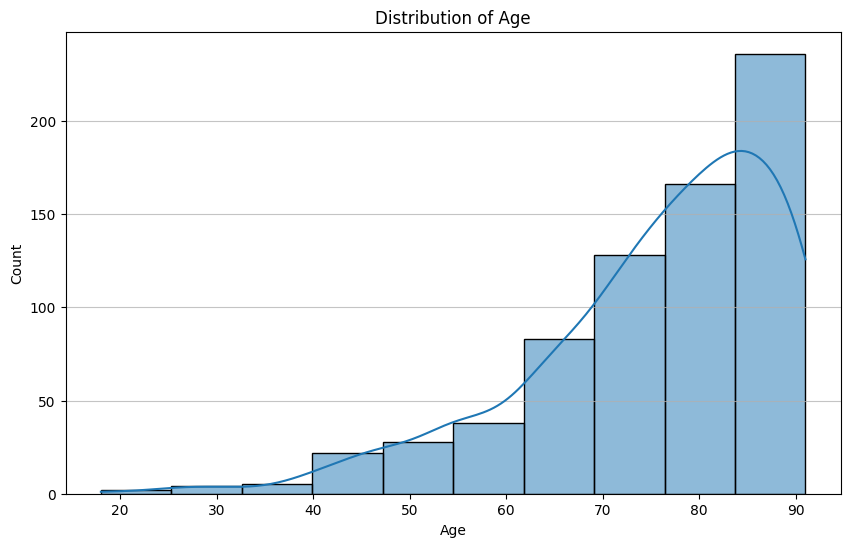

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Age
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['age'], bins=10, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

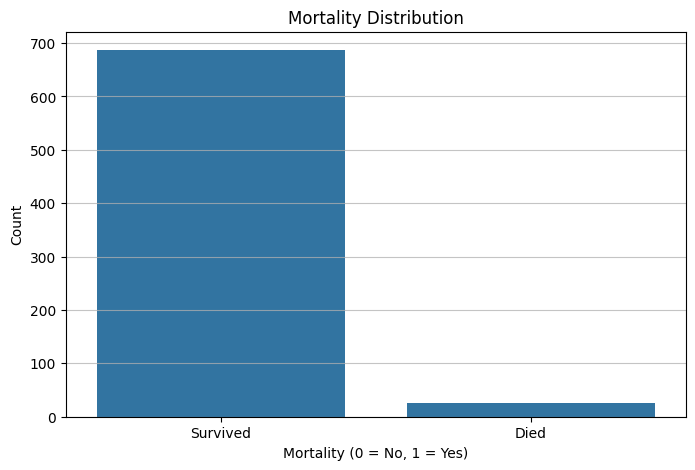

In [ ]:
# Mortality Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='mortality', data=merged_df)
plt.title('Mortality Distribution')
plt.xlabel('Mortality (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Survived', 'Died'])
plt.grid(axis='y', alpha=0.75)
plt.show()

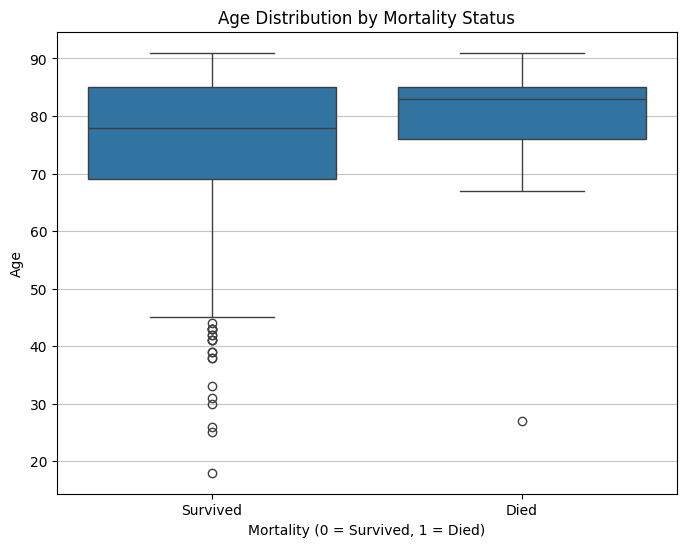

In [ ]:
# Age Distribution by Mortality Status
plt.figure(figsize=(8, 6))
sns.boxplot(x='mortality', y='age', data=merged_df)
plt.title('Age Distribution by Mortality Status')
plt.xlabel('Mortality (0 = Survived, 1 = Died)')
plt.ylabel('Age')
plt.xticks([0, 1], ['Survived', 'Died'])
plt.grid(axis='y', alpha=0.75)
plt.show()

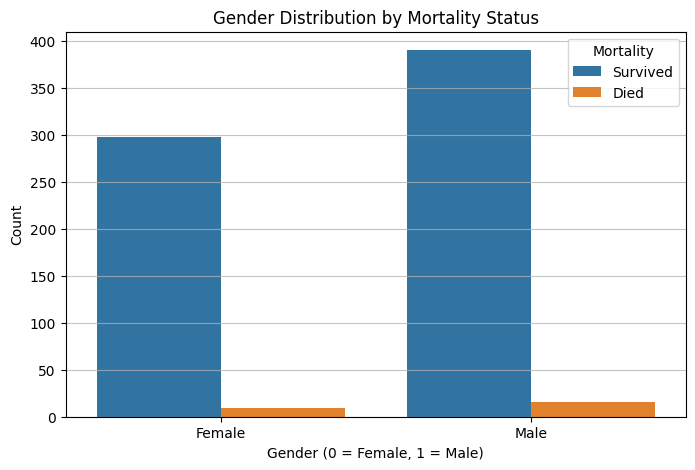

In [ ]:
# Gender Distribution by Mortality Status
plt.figure(figsize=(8, 5))
sns.countplot(x='gender', hue='mortality', data=merged_df)
plt.title('Gender Distribution by Mortality Status')
plt.xlabel('Gender (0 = Female, 1 = Male)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Female', 'Male'])
plt.legend(title='Mortality', labels=['Survived', 'Died'])
plt.grid(axis='y', alpha=0.75)
plt.show()

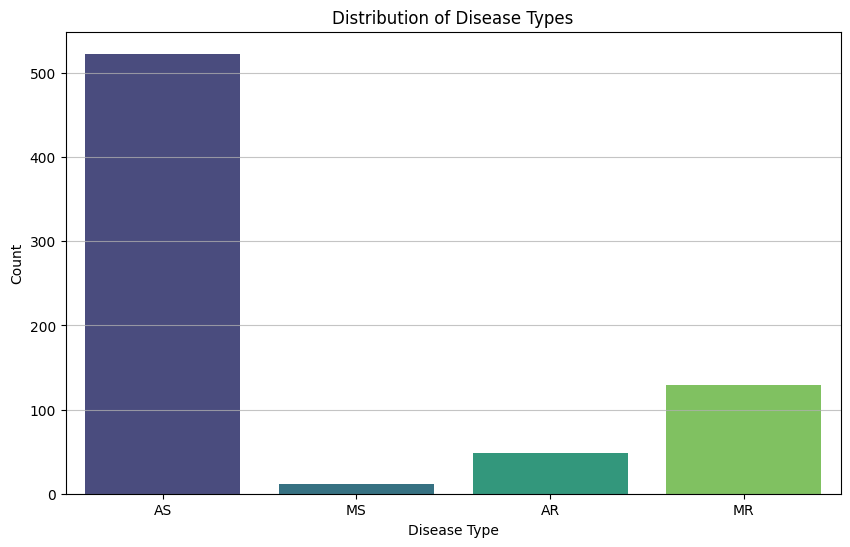

In [ ]:
# Distribution of Disease Types
plt.figure(figsize=(10, 6))
sns.countplot(x='disease_type', data=merged_df, palette='viridis', hue='disease_type', legend=False)
plt.title('Distribution of Disease Types')
plt.xlabel('Disease Type')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
df['mortality'].value_counts()

,count
mortality,
0,505
1,18


In [ ]:
print(f"\nColumns: {df.columns.tolist()}")

print(df.head())


Columns: ['hadm_id', 'subject_id', 'mortality', 'age', 'gender', 'HF', 'AF', 'CAD', 'CKD', 'COPD', 'Diabetes', 'Hypertension', 'Sepsis_IE', 'max_troponin', 'max_ntprobnp', 'first_creatinine', 'max_creatinine', 'first_urea', 'max_urea', 'min_sodium', 'max_lactate', 'min_hemoglobin', 'max_wbc', 'max_crp', 'min_bicarbonate', 'disease_type']
    hadm_id  subject_id  mortality  age  gender  HF  AF  CAD  CKD  COPD  ...  \
0  28723315    10004457          0   65       1   0   0    1    0     0  ...   
1  20015927    10017886          0   80       0   1   0    0    0     0  ...   
2  29728342    10035787          0   76       1   0   1    1    0     0  ...   
3  21350747    10051074          0   71       0   1   1    0    0     0  ...   
4  27056234    10062617          0   91       1   1   1    0    0     0  ...   

   max_creatinine  first_urea  max_urea  min_sodium  max_lactate  \
0             1.0        16.0      16.0       143.0          NaN   
1             0.7        12.0      12.0   

In [ ]:
X=merged_df.drop(['mortality','subject_id','hadm_id', 'disease_type','first_creatinine','max_creatinine','first_urea','max_urea'], axis=1)
y=merged_df['mortality']
X

,age,gender,HF,AF,CAD,CKD,COPD,Diabetes,Hypertension,Sepsis_IE,max_troponin,max_ntprobnp,min_sodium,max_lactate,min_hemoglobin,max_wbc,max_crp,min_bicarbonate
0,65,1,0,0,1,0,0,0,0,0,NaN,NaN,143.0,NaN,13.7,6.5,NaN,33.0
1,80,0,1,0,0,0,0,1,1,0,NaN,250.0,140.0,NaN,11.8,4.3,NaN,31.0
2,76,1,0,1,1,0,0,0,1,0,NaN,NaN,141.0,1.3,12.6,9.0,NaN,23.0
3,71,0,1,1,0,0,0,1,0,1,0.24,1459.0,135.0,1.8,13.8,13.2,NaN,24.0
4,91,1,1,1,0,0,0,0,0,0,NaN,NaN,133.0,NaN,10.8,6.1,NaN,27.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,81,0,0,0,1,0,0,1,1,0,3.23,NaN,134.0,NaN,11.2,8.0,NaN,22.0
708,83,1,1,1,0,1,0,0,0,0,NaN,12997.0,128.0,NaN,9.2,6.9,NaN,24.0
709,66,1,1,0,0,0,0,1,0,0,0.24,NaN,142.0,NaN,10.0,9.9,NaN,23.0
710,75,1,1,0,1,0,0,0,1,0,NaN,NaN,140.0,NaN,14.5,5.9,NaN,27.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

In [ ]:
from sklearn.impute import SimpleImputer

# Impute missing values using the median strategy
imputer = SimpleImputer(strategy='median')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Convert back to DataFrame, keeping column names
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

print("Missing values after imputation:")
print(X_train_imputed.isnull().sum().sum())
print(X_test_imputed.isnull().sum().sum())

Missing values after imputation:
0
0


In [ ]:
scalar = StandardScaler()
scaled_X_train = scalar.fit_transform(X_train)
scaled_X_test = scalar.transform(X_test)

In [ ]:
scalar = StandardScaler()
scaled_X_train = scalar.fit_transform(X_train_imputed)
scaled_X_test = scalar.transform(X_test_imputed)

# Convert scaled arrays back to DataFrame for consistency with previous steps, if needed later
scaled_X_train = pd.DataFrame(scaled_X_train, columns=X_train_imputed.columns, index=X_train_imputed.index)
scaled_X_test = pd.DataFrame(scaled_X_test, columns=X_test_imputed.columns, index=X_test_imputed.index)

In [ ]:
log_model = LogisticRegression(solver='saga',multi_class='ovr',max_iter=5000)

In [ ]:
penalty = ['l1', 'l2']
C=np.logspace(0,4,10)

In [ ]:
grid_model = GridSearchCV(log_model,param_grid={'C':C,'penalty':penalty})
grid_model.fit(scaled_X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

GridSearchCV(estimator=LogisticRegression(max_iter=5000, multi_class='ovr',
                                          solver='saga'),
             param_grid={'C': array([1.00000000e+00, 2.78255940e+00, 7.74263683e+00, 2.15443469e+01,
       5.99484250e+01, 1.66810054e+02, 4.64158883e+02, 1.29154967e+03,
       3.59381366e+03, 1.00000000e+04]),
                         'penalty': ['l1', 'l2']})

Best parameters: {'C': np.float64(1.0), 'penalty': 'l1'}

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.06      0.12       207
           1       0.03      1.00      0.07         7

    accuracy                           0.09       214
   macro avg       0.52      0.53      0.09       214
weighted avg       0.97      0.09      0.12       214


Confusion Matrix:
[[ 13 194]
 [  0   7]]

AUROC Score: 0.541


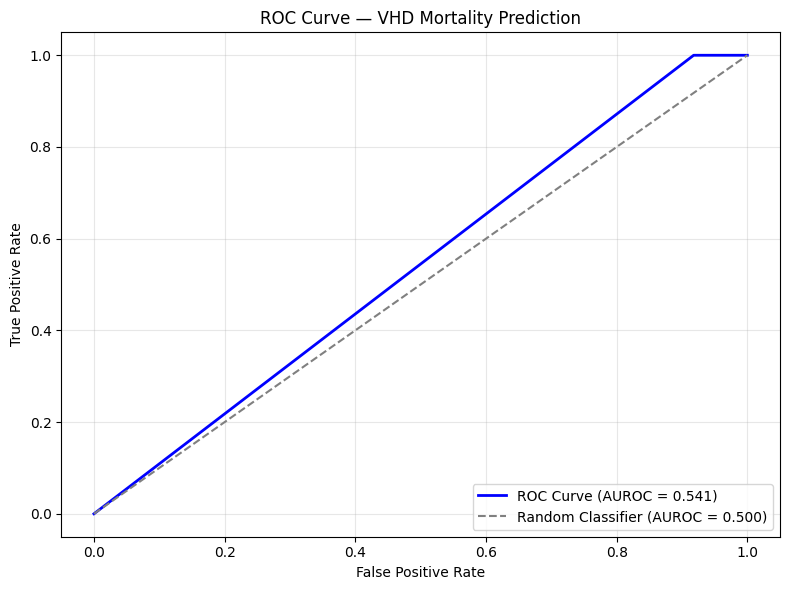

AUROC Score: 0.541


In [ ]:
y_pred = grid_model.predict(X_test_imputed)
y_prob = grid_model.predict_proba(X_test_imputed)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
print(f"Best parameters: {grid_model.best_params_}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"\nAUROC Score: {roc_auc_score(y_test, y_prob):.3f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2,
         label=f'ROC Curve (AUROC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
         label='Random Classifier (AUROC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — VHD Mortality Prediction')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUROC Score: {auc_score:.3f}")

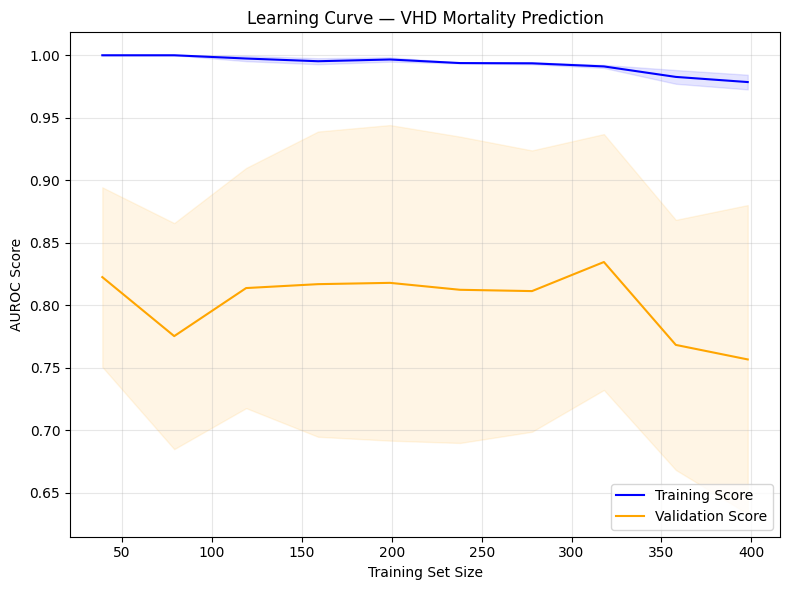

In [ ]:
#Learning curve
best_model = LogisticRegression(
    C=grid_model.best_params_['C'],
    penalty=grid_model.best_params_['penalty'],
    solver='saga',
    max_iter=5000,
    class_weight='balanced'
)

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    scaled_X_train,
    y_train,
    cv=5,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean,
         color='blue', label='Training Score')
plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.1, color='blue')
plt.plot(train_sizes, val_mean,
         color='orange', label='Validation Score')
plt.fill_between(train_sizes,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.1, color='orange')

plt.xlabel('Training Set Size')
plt.ylabel('AUROC Score')
plt.title('Learning Curve — VHD Mortality Prediction')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
accuracy_score(y_test,y_pred)

0.09345794392523364

In [ ]:

print("Predicted values:")
print(pd.Series(y_pred).value_counts())

print("\nActual values in test set:")
print(y_test.value_counts())

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print(f"\nBest parameters found: {grid_model.best_params_}")

Predicted values:
1    201
0     13
Name: count, dtype: int64

Actual values in test set:
mortality
0    207
1      7
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.06      0.12       207
           1       0.03      1.00      0.07         7

    accuracy                           0.09       214
   macro avg       0.52      0.53      0.09       214
weighted avg       0.97      0.09      0.12       214


Confusion Matrix:
[[ 13 194]
 [  0   7]]

Best parameters found: {'C': np.float64(1.2915496650148828), 'penalty': 'l1'}
